# Credit Card Transaction Analysis & Customer Spending Insights Using Python, Pandas, Matplotlib, and Seaborn

# Importing libraries :-

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset :-

In [103]:
df = pd.read_csv('credit_card_transactions.csv')

In [104]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [105]:
df.tail()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,NaN
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,22630.0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,88351.0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,69367.0
1296674,1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,...,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0,59870.0


In [106]:
df.shape

(1296675, 24)

In [107]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='object')

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [109]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.100702e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03,4.682575e+04
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02,2.583400e+04
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00,1.001000e+03
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00,2.511400e+04
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00,4.586000e+04
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00,6.831900e+04
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00,9.940300e+04


# Data Cleaning :-

In [110]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [111]:
df.drop_duplicates(inplace=True)


In [112]:
df.rename(columns={
    'trans_date_trans_time': 'transaction_date',
    'amt': 'amount',
    'cust_id': 'customer_id'
}, inplace=True)

In [113]:
# Convert USD to INR (approx rate)
df['amount_inr'] = df['amount'] * 93

In [114]:
df[['amount', 'amount_inr']].head()

,amount,amount_inr
0,4.97,462.21
1,107.23,9972.39
2,220.11,20470.23
3,45.00,4185.00
4,41.96,3902.28


In [115]:
df.columns = df.columns.str.strip()

In [116]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

In [117]:
df.rename(columns={'Unnamed: 0': 'customer_id'}, inplace=True)

In [118]:
df = df.dropna()

# Business Metrics :-

In [119]:
total_revenue = df['amount_inr'].sum()
avg_transaction = df['amount_inr'].mean()
total_customers = df['customer_id'].nunique()

print("Total Revenue:", total_revenue)
print("Average Transaction Value:", avg_transaction)
print("Total Customers:", total_customers)

Total Revenue: 7190406406.560002
Average Transaction Value: 6532.564133216803
Total Customers: 1100702


# Exploratory Data Analysis (EDA) :-

# Data Visualization :-

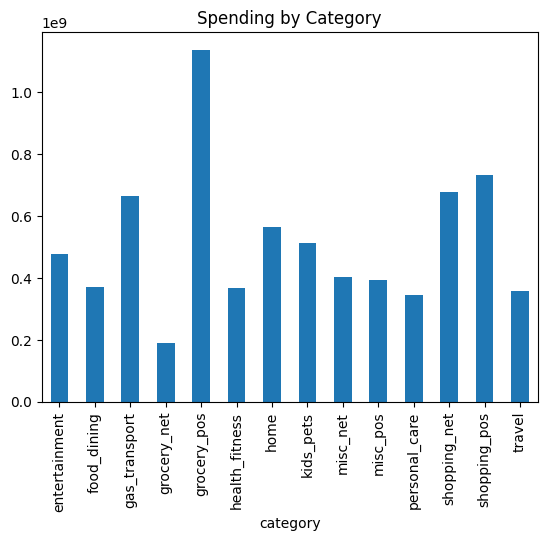

In [120]:
# Spending by Category
df.groupby('category')['amount_inr'].sum().plot(kind='bar')
plt.title("Spending by Category")
plt.show()

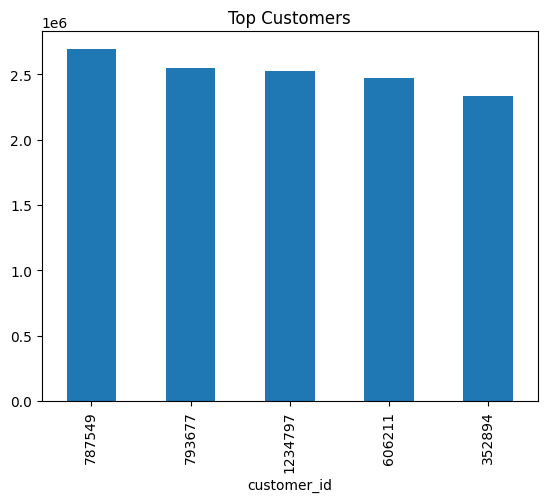

In [121]:
# Top 5 Customers
df.groupby('customer_id')['amount_inr'].sum().sort_values(ascending=False).head(5).plot(kind='bar')
plt.title("Top Customers")
plt.show()

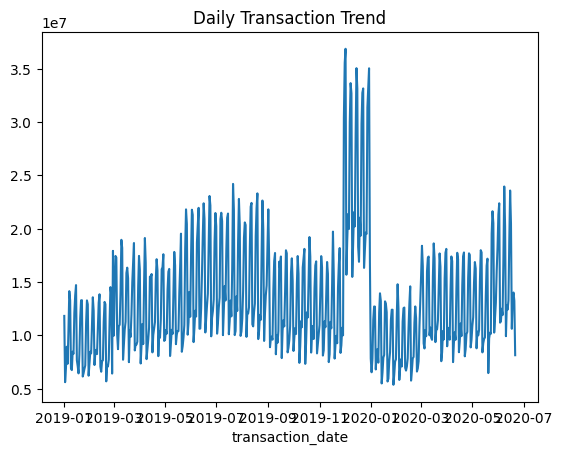

In [122]:
# Daily Transaction Trend
df.groupby(df['transaction_date'].dt.date)['amount_inr'].sum().plot()
plt.title("Daily Transaction Trend")
plt.show()

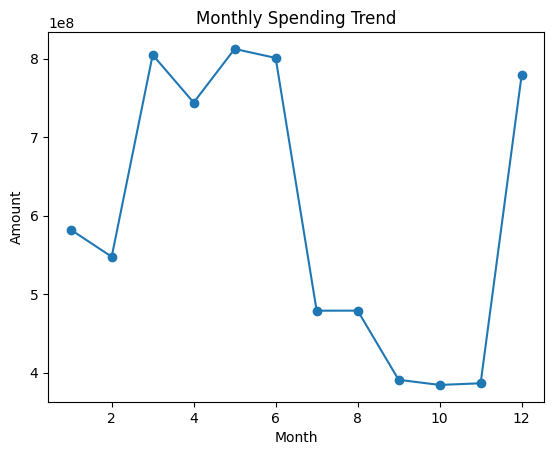

In [123]:
# Monthly Trend
df['month'] = df['transaction_date'].dt.month

df.groupby('month')['amount_inr'].sum().plot(kind='line', marker='o')
plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.show()

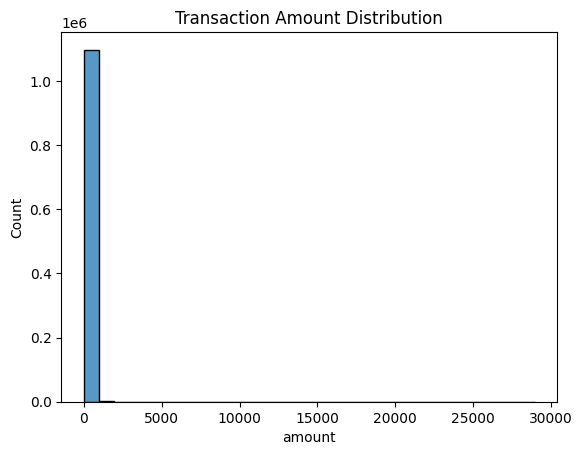

In [130]:
# Transaction Amount Distribution
sns.histplot(df['amount'], bins=30)
plt.title("Transaction Amount Distribution")
plt.show()

# Segmentation :-

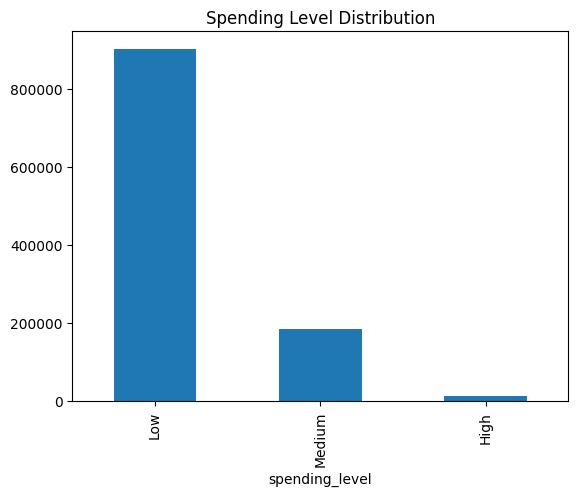

In [124]:
# Spending Level
df['spending_level'] = df['amount'].apply(
    lambda x: 'Low' if x < 100 else 'Medium' if x < 500 else 'High'
)

df['spending_level'].value_counts().plot(kind='bar')
plt.title("Spending Level Distribution")
plt.show()

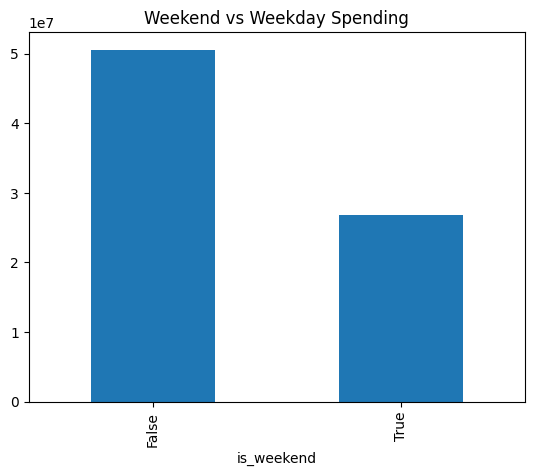

In [125]:
# Weekend vs Weekday
df['day'] = df['transaction_date'].dt.day_name()

df['is_weekend'] = df['day'].isin(['Saturday', 'Sunday'])

df.groupby('is_weekend')['amount'].sum().plot(kind='bar')
plt.title("Weekend vs Weekday Spending")
plt.show()

In [126]:
# Top & Bottom Categories
category_spending = df.groupby('category')['amount'].sum().sort_values(ascending=False)

print("Top Categories:\n", category_spending.head())
print("\nBottom Categories:\n", category_spending.tail())


Top Categories:
 category
grocery_pos      12224385.74
shopping_pos      7874704.92
shopping_net      7285106.05
gas_transport     7134452.04
home              6080632.49
Name: amount, dtype: float64

Bottom Categories:
 category
food_dining       3977089.87
health_fitness    3945387.59
travel            3845702.32
personal_care     3696173.14
grocery_net       2055404.61
Name: amount, dtype: float64


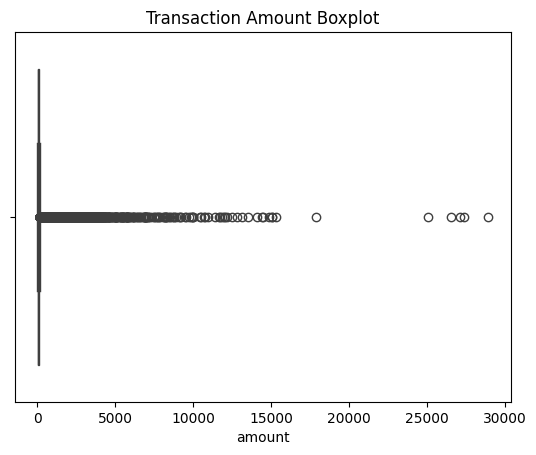

In [127]:
sns.boxplot(x=df['amount'])
plt.title("Transaction Amount Boxplot")
plt.show()

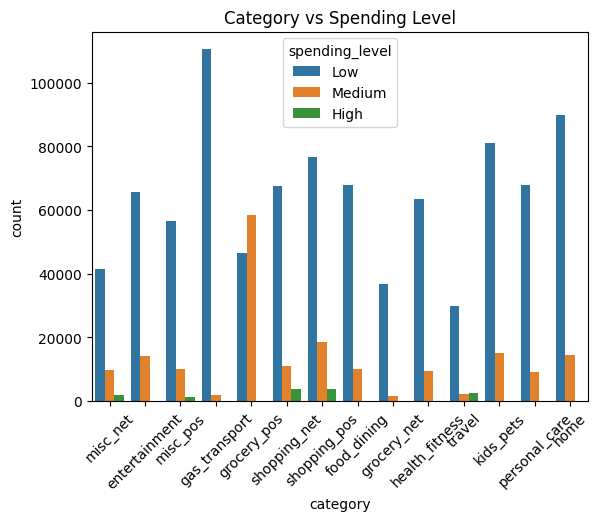

In [128]:
sns.countplot(x='category', hue='spending_level', data=df)
plt.title("Category vs Spending Level")
plt.xticks(rotation=45)
plt.show()

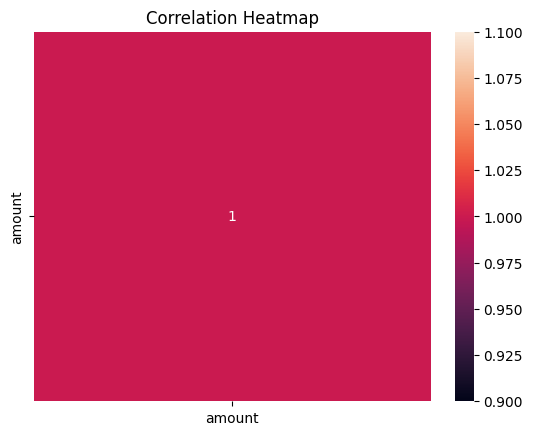

In [129]:
sns.heatmap(df[['amount']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## 📌 Key Insights

- Transactions are highly concentrated in key categories such as **shopping** and **food**.  
- A small segment of customers contributes a large portion of **total revenue**.  
- Spending behavior shows clear **monthly trends and variations**.  
- Most transactions fall under **low to medium spending levels**, indicating regular usage patterns.  
- **Weekend transactions** show different patterns compared to weekdays.  
- **High-value transactions**, although fewer, contribute significantly to revenue.  